In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))  # Adjust path to root directory ml_project

from src.utils.utils import load_file

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Original Restautant dataset
df_restaurant_food = load_file('../../data/kaggle/Restaurant_food_consumption_upd.csv')

# Restaurant food with ingredient quantities
restaurant_file = '../../data/kaggle/Restaurant_food_quantities.csv' 
df_restaurant_food_quantities = load_file(restaurant_file)

**N=25 Most Frequent Ingredients**

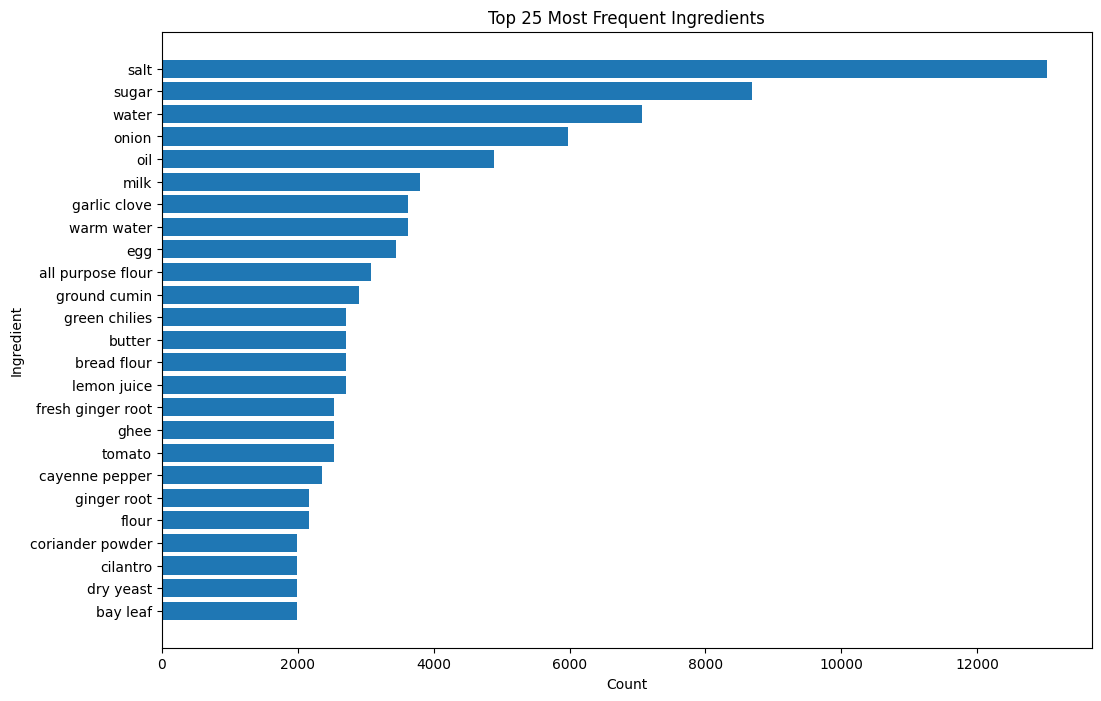

In [8]:
# Determine the 25 most frequent ingredients
top_n = 25
df_ingredients_counts = (df_restaurant_food_quantities
                         .groupby('Ingredient')
                         .size()
                         .sort_values(ascending=False).rename('Count').reset_index())

plt.figure(figsize=(12, 8))

top_ingredients = df_ingredients_counts.head(top_n)
plt.barh(top_ingredients['Ingredient'], top_ingredients['Count'])
plt.xlabel('Count')
plt.ylabel('Ingredient')
plt.title(f'Top {top_n} Most Frequent Ingredients')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count at the top
plt.show()

**N=25 Most Frequent Ingredients - without water, warm water and oil**

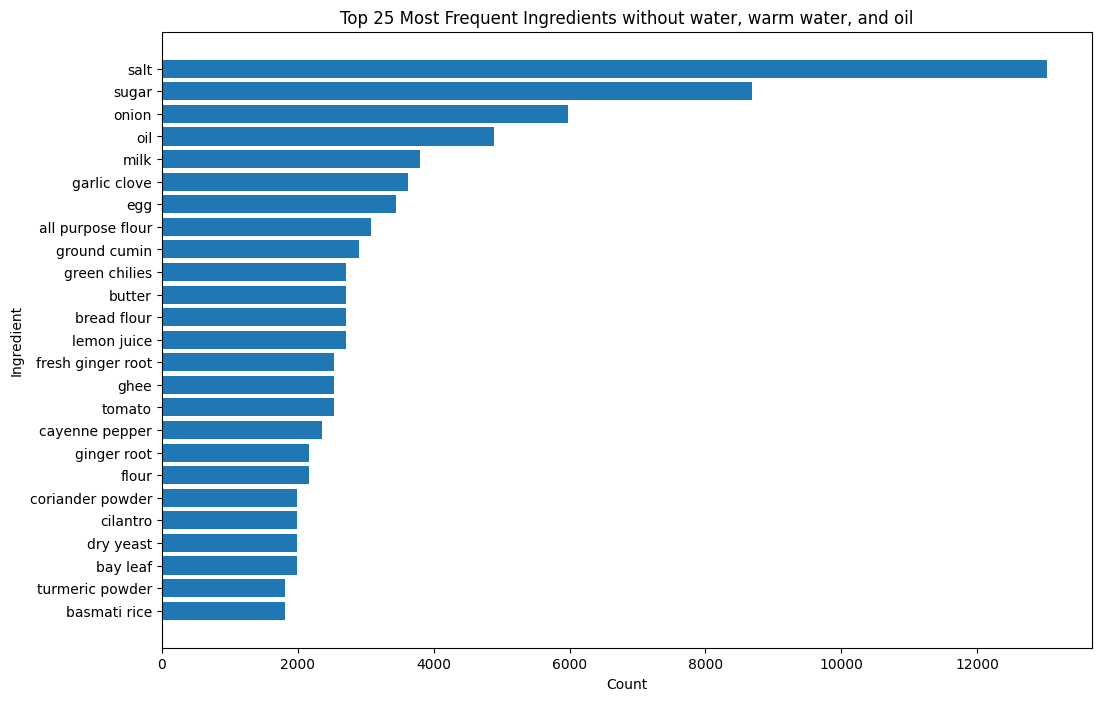

In [4]:
# Determine the 25 most frequent ingredients
top_n = 25

df_ingredients_counts = (df_restaurant_food_quantities
                         .groupby('Ingredient')
                         .size()
                         .sort_values(ascending=False).rename('Count').reset_index())

# Ingredients to remove
ingredients_to_remove = ['water', 'warm water']
df_ingredients_counts = df_ingredients_counts[~df_ingredients_counts['Ingredient'].isin(ingredients_to_remove)]

# Get the 25 most frequent ingredients dataframe 
df_most_freq_ings = df_ingredients_counts.head(top_n)

plt.figure(figsize=(12, 8))

top_ingredients = df_most_freq_ings
plt.barh(top_ingredients['Ingredient'], top_ingredients['Count'])
plt.xlabel('Count')
plt.ylabel('Ingredient')
plt.title(f'Top {top_n} Most Frequent Ingredients without water, warm water, and oil')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count at the top
plt.show()

In [5]:
# Filter restaurant dataset by 25 most frequent ingredients

# Get the list of the 25 most frequent ingredients
most_freq_ings_list = df_most_freq_ings['Ingredient'].to_list()

df_restaurant_freq_ings = (df_restaurant_food_quantities[df_restaurant_food_quantities['Ingredient']
                                                         .isin(most_freq_ings_list)].reset_index(drop=True))

In [6]:
# Check how many recipes and orders remained 
groupby_columns = ['OrderID', 'MenuItem']
df_test = df_restaurant_freq_ings.groupby(groupby_columns).size().reset_index()
print("Number of recipes: ", len(df_test['MenuItem'].value_counts()))
print("Number of total orders: ", len(df_test))

print("-------------------------------------------")

# Find the missing recipe and check if the values make sense
unique_recipes_orig = df_restaurant_food['MenuItem'].drop_duplicates()
unique_recipes_freq = df_restaurant_freq_ings['MenuItem'].drop_duplicates()
missing_recipes = set(unique_recipes_orig) - set(unique_recipes_freq)
print("Missing recipes: ", missing_recipes)
print("Missing recipe orders: ", len(df_restaurant_food[df_restaurant_food['MenuItem'].isin(list(missing_recipes))]))


Number of recipes:  42
Number of total orders:  17919
-------------------------------------------
Missing recipes:  {'spinach naan'}
Missing recipe orders:  181


In [7]:
# Convert the 'Date_time' column to datetime
# df_restaurant_freq_ings['Date_time'] = pd.to_datetime(df_restaurant_freq_ings['Date_time'])

# # Extract year, month, day, hour, minute into separate columns
# df_restaurant_freq_ings.insert(1, 'Day', df_restaurant_freq_ings['Date_time'].dt.day)
# df_restaurant_freq_ings.insert(2, 'Month', df_restaurant_freq_ings['Date_time'].dt.month)
# df_restaurant_freq_ings.insert(3, 'Year', df_restaurant_freq_ings['Date_time'].dt.year)
# df_restaurant_freq_ings.insert(4, 'Hour', df_restaurant_freq_ings['Date_time'].dt.hour)
# df_restaurant_freq_ings.insert(5, 'Minute', df_restaurant_freq_ings['Date_time'].dt.minute)